# Homework 4: Unsupervised Learning

Solutions to Exercises 1, 2, 3, 5, and 6 (numbering follows the assignment sheet, which jumps from Exercise 3 to Exercise 5). Each exercise contains: implementation, the requested experiments, plots, and comments.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True


## Exercise 1: Compute the SVD of a Matrix & Verify the Reconstruction

**1-2. Construct a non-square matrix and compute its SVD.**

In [2]:
rng = np.random.default_rng(0)

m, n = 10, 6
A = rng.normal(size=(m, n))
print("A shape:", A.shape)

U, S, Vt = np.linalg.svd(A, full_matrices=True)
print("U shape:", U.shape, " S shape:", S.shape, " Vt shape:", Vt.shape)


A shape: (10, 6)
U shape: (10, 10)  S shape: (6,)  Vt shape: (6, 6)


**3. Verify the reconstruction** $A \approx U\Sigma V^T$.

In [3]:
Sigma = np.zeros((m, n))
np.fill_diagonal(Sigma, S)

A_reconstructed = U @ Sigma @ Vt
recon_error = np.linalg.norm(A - A_reconstructed, ord='fro')
print(f"||A - U Sigma V^T||_F = {recon_error:.3e}")


||A - U Sigma V^T||_F = 4.516e-15


**4. Singular values.**

Singular values: [4.82910775 3.4230114  2.53935329 2.01193915 1.37390916 1.12378003]


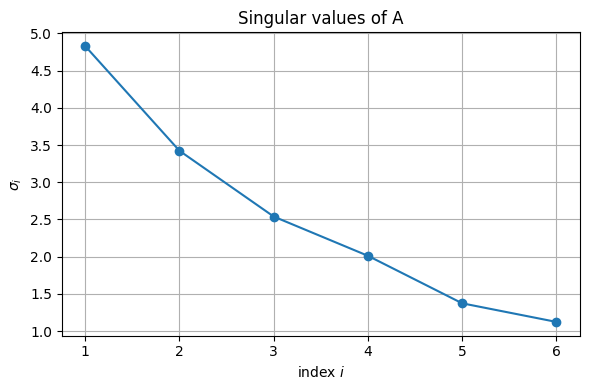

In [4]:
print("Singular values:", S)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(np.arange(1, len(S)+1), S, 'o-', color='tab:blue')
ax.set_xlabel('index $i$')
ax.set_ylabel(r'$\sigma_i$')
ax.set_title('Singular values of A')
plt.tight_layout()
plt.show()


**5. Comments.**

- **Why singular values appear in descending order**: this is a convention built into the definition/computation of the SVD, chosen so that $\sigma_1$ always captures the direction of largest variance/energy in the data, $\sigma_2$ the largest remaining orthogonal direction, and so on. Ordering them this way makes truncating the SVD (keeping only the first $k$ terms) meaningful: it always keeps the $k$ *most important* directions, rather than an arbitrary subset.
- **Why small singular values correspond to "less important" directions**: each term $\sigma_i u_i v_i^T$ contributes $\sigma_i$ to the Frobenius norm of $A$ (since $\|A\|_F^2=\sum_i \sigma_i^2$), so a small $\sigma_i$ means that rank-one component contributes very little to reconstructing $A$; dropping it barely changes $A$ in the least-squares sense that the Frobenius norm measures. This is exactly why keeping only the top-$k$ singular values/vectors gives a good low-rank approximation, as explored in Exercise 2.
- **Why floating-point arithmetic makes exact zeros rare**: even if the "true" matrix $A$ is mathematically rank-deficient (e.g. some rows/columns are exact linear combinations of others), floating-point representation and the numerical algorithms used to compute the SVD (Householder reflections, QR iterations, etc.) introduce tiny rounding errors at every step. These errors typically make the singular values that should be exactly zero come out as extremely small but non-zero numbers (e.g. $10^{-15}$ or $10^{-16}$, close to machine epsilon) instead of being exactly $0.0$.

## Exercise 2: Best Rank-$k$ Approximation

**1. Rank-$k$ approximation function.**

In [5]:
def rank_k_approx(U, S, Vt, k):
    """Reconstruct the rank-k approximation A_k = sum_{i=1}^k sigma_i u_i v_i^T."""
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

# sanity check: rank-min(m,n) approximation should equal A itself
A_full_rank = rank_k_approx(U, S, Vt, min(m, n))
print("Sanity check, ||A - A_full||_F =", np.linalg.norm(A - A_full_rank, ord='fro'))


Sanity check, ||A - A_full||_F = 4.515508283129705e-15


**2-3. Approximation error $E(k)=\|A-A_k\|_F$ vs $k$.**

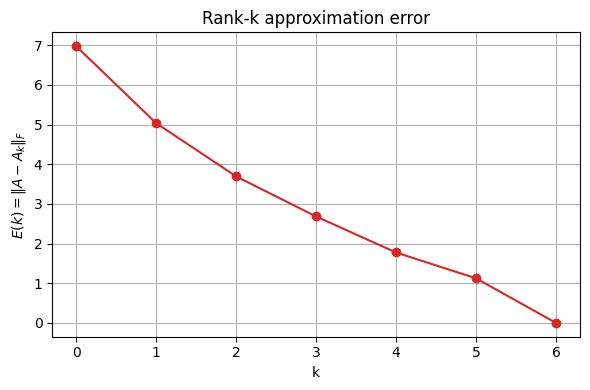

k=0: E(k)=6.9774e+00,  sqrt(sum sigma_i^2 for i>k)=6.9774e+00
k=1: E(k)=5.0362e+00,  sqrt(sum sigma_i^2 for i>k)=5.0362e+00
k=2: E(k)=3.6941e+00,  sqrt(sum sigma_i^2 for i>k)=3.6941e+00
k=3: E(k)=2.6830e+00,  sqrt(sum sigma_i^2 for i>k)=2.6830e+00
k=4: E(k)=1.7750e+00,  sqrt(sum sigma_i^2 for i>k)=1.7750e+00
k=5: E(k)=1.1238e+00,  sqrt(sum sigma_i^2 for i>k)=1.1238e+00
k=6: E(k)=4.5155e-15,  sqrt(sum sigma_i^2 for i>k)=0.0000e+00


In [6]:
ks = np.arange(0, min(m, n) + 1)
errors = []
for k in ks:
    if k == 0:
        A_k = np.zeros_like(A)
    else:
        A_k = rank_k_approx(U, S, Vt, k)
    errors.append(np.linalg.norm(A - A_k, ord='fro'))
errors = np.array(errors)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(ks, errors, 'o-', color='tab:red')
ax.set_xlabel('k')
ax.set_ylabel(r'$E(k) = \|A - A_k\|_F$')
ax.set_title('Rank-k approximation error')
plt.tight_layout()
plt.show()

for k in ks:
    print(f"k={k}: E(k)={errors[k]:.4e},  sqrt(sum sigma_i^2 for i>k)={np.sqrt(np.sum(S[k:]**2)):.4e}")


**4. Why SVD gives the optimal rank-$k$ approximation.**

The **Eckart-Young-Mirsky theorem** states that, among *all* matrices $B$ of rank at most $k$, the truncated SVD $A_k=\sum_{i=1}^k \sigma_i u_i v_i^T$ is the one that minimizes $\|A-B\|_F$ (and also $\|A-B\|_2$), and the minimal error is exactly $E(k)=\sqrt{\sum_{i=k+1}^{\min(m,n)}\sigma_i^2}$ — which is precisely what the numerical values printed above confirm. Intuitively, this is because the SVD decomposes $A$ into mutually **orthogonal** rank-one components ordered by how much of $A$'s "energy" (squared Frobenius norm) each one carries; keeping the $k$ components with the largest $\sigma_i$ and discarding the rest is, by orthogonality, exactly equivalent to minimizing the sum of squared discarded singular values — and no other choice of $k$ directions (whether from a different basis or a different subset of singular directions) can capture more of that energy with only $k$ degrees of freedom. This optimality is exactly what justifies using SVD/PCA for compression and dimensionality reduction, as done in Exercises 3, 5, and 6.

## Exercise 3: Image Compression with SVD

**1. Load the `cameraman` image** ($512\times512$), a classic image-processing test image (obtained here via `skimage.data.camera()`, equivalent to the image used in the lecture notes).

Image shape: (512, 512)  dtype range: 0.0 255.0


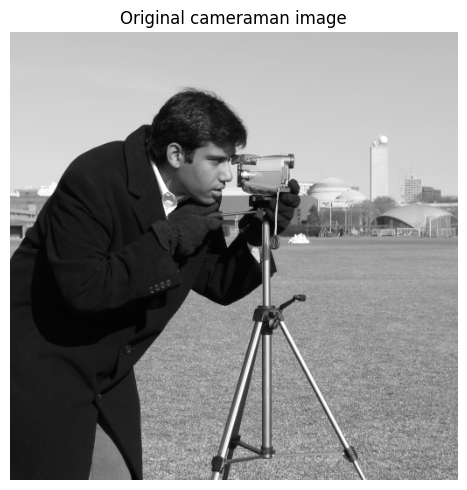

In [7]:
from skimage import data

X_img = data.camera().astype(float)
print("Image shape:", X_img.shape, " dtype range:", X_img.min(), X_img.max())

fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(X_img, cmap='gray')
ax.set_title('Original cameraman image')
ax.axis('off')
plt.tight_layout()
plt.show()


**2. Compute its SVD.**

In [8]:
U_img, S_img, Vt_img = np.linalg.svd(X_img, full_matrices=False)
print("U:", U_img.shape, " S:", S_img.shape, " Vt:", Vt_img.shape)

m_img, n_img = X_img.shape


U: (512, 512)  S: (512,)  Vt: (512, 512)


**3. Rank-$k$ reconstructions, reconstruction error, and compression factor** for $k\in\{5,20,50,100,200\}$, using

$$c_k = 1 - \frac{k(m+n+1)}{mn}.$$

In [9]:
ks_img = [5, 20, 50, 100, 200]

def compression_factor(k, m_, n_):
    return 1 - (k*(m_ + n_ + 1)) / (m_*n_)

reconstructions = {}
errors_img = {}
comp_factors = {}
for k in ks_img:
    Xk = rank_k_approx(U_img, S_img, Vt_img, k)
    reconstructions[k] = Xk
    errors_img[k] = np.linalg.norm(X_img - Xk, ord='fro')
    comp_factors[k] = compression_factor(k, m_img, n_img)
    print(f"k={k:>4d}:  error={errors_img[k]:>10.2f}   compression factor c_k={comp_factors[k]:.4f}")


k=   5:  error=  13086.87   compression factor c_k=0.9804
k=  20:  error=   7699.91   compression factor c_k=0.9218
k=  50:  error=   4836.07   compression factor c_k=0.8045
k= 100:  error=   2992.14   compression factor c_k=0.6090
k= 200:  error=   1342.36   compression factor c_k=0.2180


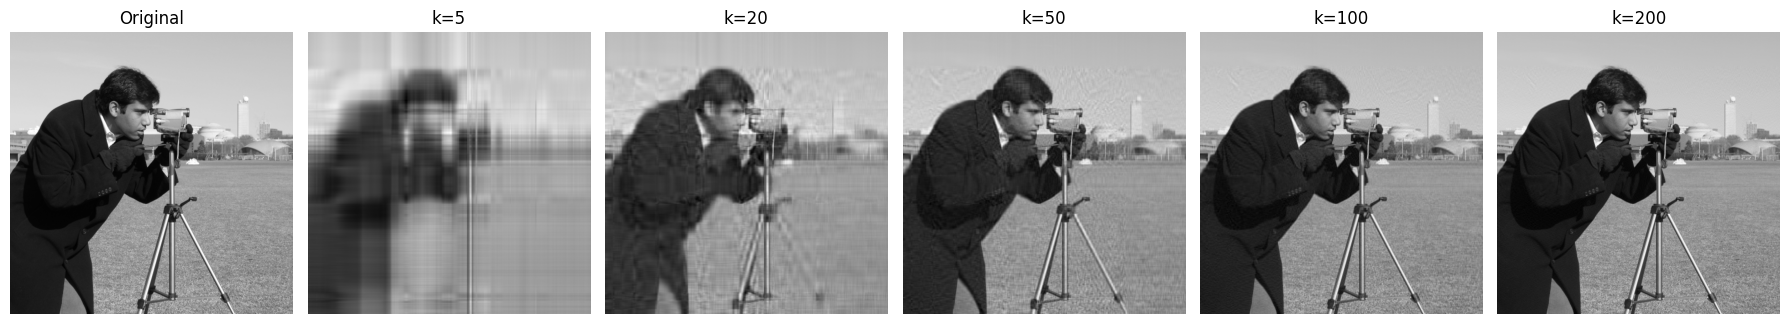

In [10]:
fig, axes = plt.subplots(1, len(ks_img)+1, figsize=(3*(len(ks_img)+1), 3.2))

axes[0].imshow(X_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for ax, k in zip(axes[1:], ks_img):
    ax.imshow(reconstructions[k], cmap='gray')
    ax.set_title(f'k={k}')
    ax.axis('off')

plt.tight_layout()
plt.show()


**Reconstruction error and compression factor vs $k$** (over a finer grid of $k$ values, for a smoother picture).

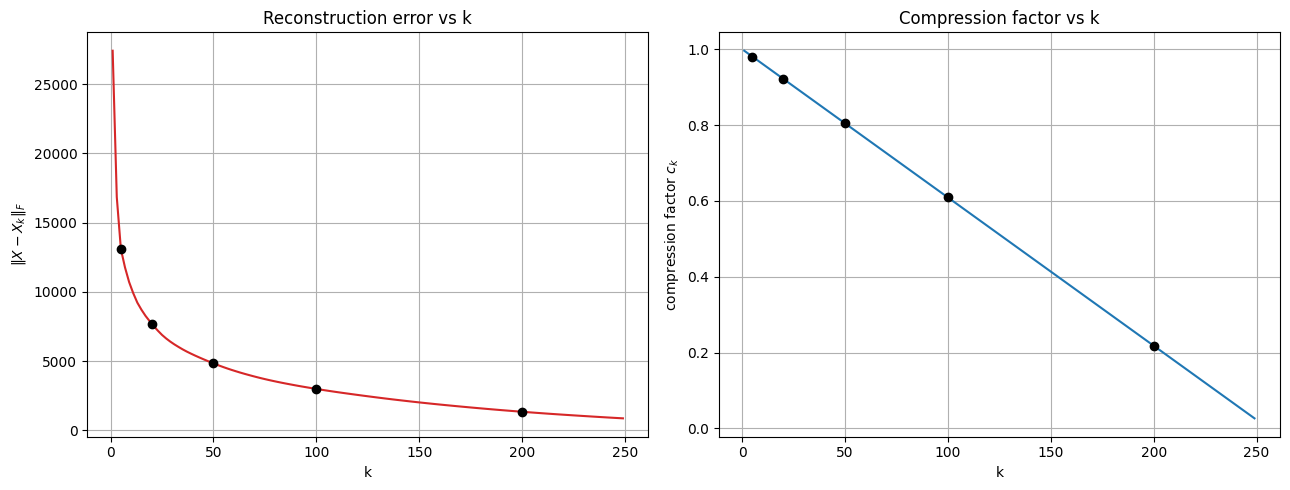

In [11]:
ks_fine = np.arange(1, 250, 2)
errors_fine = [np.linalg.norm(X_img - rank_k_approx(U_img, S_img, Vt_img, k), ord='fro') for k in ks_fine]
comp_fine = [compression_factor(k, m_img, n_img) for k in ks_fine]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ks_fine, errors_fine, color='tab:red')
axes[0].scatter(ks_img, [errors_img[k] for k in ks_img], color='black', zorder=5)
axes[0].set_xlabel('k')
axes[0].set_ylabel(r'$\|X - X_k\|_F$')
axes[0].set_title('Reconstruction error vs k')

axes[1].plot(ks_fine, comp_fine, color='tab:blue')
axes[1].scatter(ks_img, [comp_factors[k] for k in ks_img], color='black', zorder=5)
axes[1].set_xlabel('k')
axes[1].set_ylabel(r'compression factor $c_k$')
axes[1].set_title('Compression factor vs k')

plt.tight_layout()
plt.show()


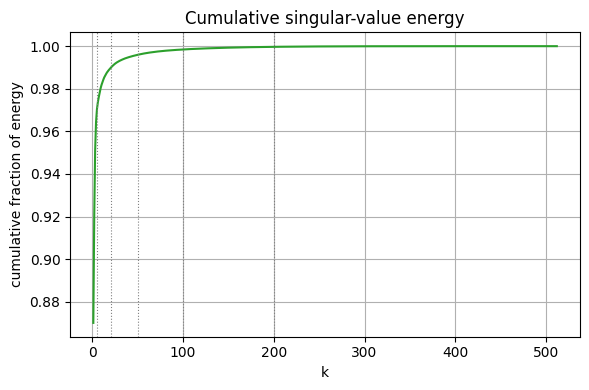

k=   5: cumulative energy fraction = 0.9704
k=  20: cumulative energy fraction = 0.9898
k=  50: cumulative energy fraction = 0.9960
k= 100: cumulative energy fraction = 0.9985
k= 200: cumulative energy fraction = 0.9997


In [12]:
# Where is the "energy" of the image concentrated?
energy = S_img**2
cumulative_energy = np.cumsum(energy) / np.sum(energy)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(np.arange(1, len(S_img)+1), cumulative_energy, color='tab:green')
for k in ks_img:
    ax.axvline(k, color='gray', ls=':', lw=0.8)
ax.set_xlabel('k')
ax.set_ylabel('cumulative fraction of energy')
ax.set_title('Cumulative singular-value energy')
plt.tight_layout()
plt.show()

for k in ks_img:
    print(f"k={k:>4d}: cumulative energy fraction = {cumulative_energy[k-1]:.4f}")


**4. Comments.**

- **Visual quality vs $k$**: at $k=5$ the reconstruction is a blurry, low-frequency approximation of the image (large-scale shapes and overall contrast are visible, but fine details are lost). As $k$ increases (20, 50, 100), progressively finer textures and edges reappear, and by $k=200$ (out of $512$) the reconstruction is visually almost indistinguishable from the original, even though it uses well under half of the singular values.
- **Why most of the "energy" is contained in the first singular values**: natural images are highly **spatially correlated** — nearby pixels tend to have similar intensities, and large regions share smooth gradients or repeated textures. This redundancy means the effective rank of the pixel matrix is much lower than $\min(m,n)$, so a small number of singular vectors (capturing the dominant, large-scale patterns of variation) already reconstruct most of the image's energy $\sum\sigma_i^2$, as confirmed by the steep initial rise of the cumulative-energy curve above; the remaining singular values mostly encode fine detail and noise, which contribute comparatively little to the total Frobenius energy.
- **Trade-off between compression and fidelity**: the compression factor $c_k$ decreases as $k$ grows (storing $U_{:,:k}$, $\Sigma_{:k}$, and $V_{:,:k}^T$ costs $k(m+n+1)$ numbers instead of the original $mn$), while the reconstruction error $E(k)$ also decreases with $k$ — so there is a direct trade-off: a small $k$ gives high compression but lower fidelity, while a large $k$ gives high fidelity but little compression benefit. Because of the concentrated-energy property above, a "sweet spot" ($k\approx 50$-$100$ here) typically achieves most of the achievable fidelity while still discarding a majority of the singular directions.
- **Connection to optimal low-rank approximation**: as established in Exercise 2 (Eckart-Young theorem), for every fixed $k$, the truncated-SVD reconstruction $X_k$ is *provably* the closest possible rank-$k$ matrix to $X$ in Frobenius norm. This means the error/compression trade-off curves shown above are not just "good", but the **best achievable** trade-off for any rank-$k$ image compression scheme based on this criterion — no other rank-$k$ matrix could achieve a lower reconstruction error at the same compression level.

## Exercise 5: PCA + Clustering on a Real Dataset

We use the MNIST handwritten-digits dataset (same data as the [Kaggle MNIST Digit Recognizer dataset](https://www.kaggle.com/datasets/animatronbot/mnist-digit-recognizer); since Kaggle requires authenticated downloads, we reconstruct an equivalent CSV directly from the original MNIST binary files via a public GitHub mirror, and use a class-balanced subsample of 25 000 images — 2 500 per digit — to keep computation light). As instructed, we filter only digits 3 and 4 first.

**1-2. Load the CSV and split into train/test.**

In [13]:
df_mnist = pd.read_csv('mnist.csv')
print(df_mnist.shape)
print(df_mnist['label'].value_counts().sort_index())

def load_digit_pair(df, digit0, digit1, test_frac=0.2, seed=0):
    """Filter two digit classes, encode digit1 as label 1 and digit0 as label 0,
    and split into train/test sets."""
    sub = df[df['label'].isin([digit0, digit1])]
    X = sub.drop(columns='label').values.astype(float)
    y = (sub['label'].values == digit1).astype(int)  # 0 -> digit0, 1 -> digit1
    rng_ = np.random.default_rng(seed)
    idx = rng_.permutation(len(X))
    n_test = int(len(X) * test_frac)
    test_idx, train_idx = idx[:n_test], idx[n_test:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

X_train_34, y_train_34, X_test_34, y_test_34 = load_digit_pair(df_mnist, 3, 4, seed=5)
print(f"train: {X_train_34.shape}, test: {X_test_34.shape}")


(25000, 785)
label
0    2500
1    2500
2    2500
3    2500
4    2500
5    2500
6    2500
7    2500
8    2500
9    2500
Name: count, dtype: int64


train: (4000, 784), test: (1000, 784)


**3-4. Center the training data and compute the reduced SVD of the centered data.**

In [14]:
def pca_fit(X_train_, k):
    mean_ = X_train_.mean(axis=0)
    Xc = X_train_ - mean_
    U_, S_, Vt_ = np.linalg.svd(Xc, full_matrices=False)
    P_ = Vt_[:k, :].T   # (d, k), columns are the top-k principal directions
    return mean_, P_, S_

def pca_project(X_, mean_, P_):
    return (X_ - mean_) @ P_

mean_34, P2_34, S_34 = pca_fit(X_train_34, k=2)
print("Top singular values (3 vs 4):", S_34[:5])


Top singular values (3 vs 4): [47251.35572448 30513.59045011 27745.19626811 25550.29235994
 23742.60383204]


**5-7. Project onto $k=2$ principal components and plot the scatter of train (colored by label) and test (overlaid) sets.**

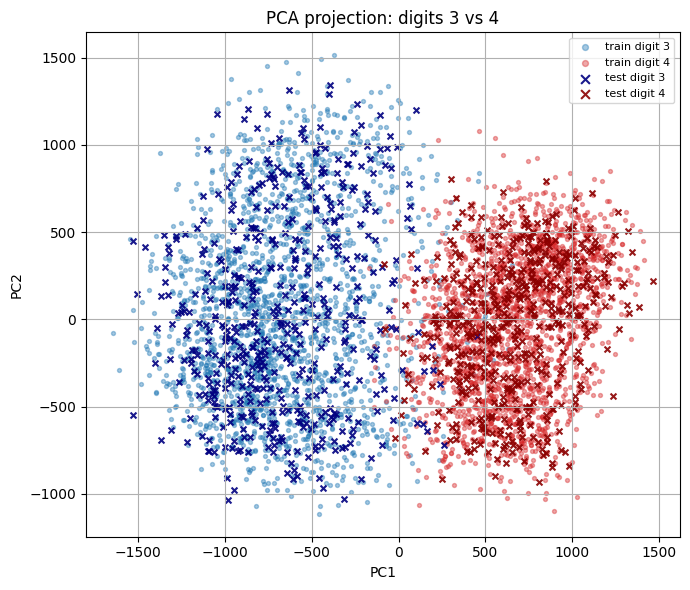

In [15]:
Z_train_34 = pca_project(X_train_34, mean_34, P2_34)
Z_test_34 = pca_project(X_test_34, mean_34, P2_34)

fig, ax = plt.subplots(figsize=(7,6))
for cls, name, color in [(0, 'digit 3', 'tab:blue'), (1, 'digit 4', 'tab:red')]:
    mask_tr = y_train_34 == cls
    ax.scatter(Z_train_34[mask_tr,0], Z_train_34[mask_tr,1], s=8, alpha=0.4, color=color, label=f'train {name}')
for cls, name, color in [(0, 'digit 3', 'navy'), (1, 'digit 4', 'darkred')]:
    mask_te = y_test_34 == cls
    ax.scatter(Z_test_34[mask_te,0], Z_test_34[mask_te,1], s=18, alpha=0.9, color=color,
               marker='x', label=f'test {name}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('PCA projection: digits 3 vs 4')
ax.legend(markerscale=1.5, fontsize=8)
plt.tight_layout()
plt.show()


**8. Repeat with digits 5 vs 8.**

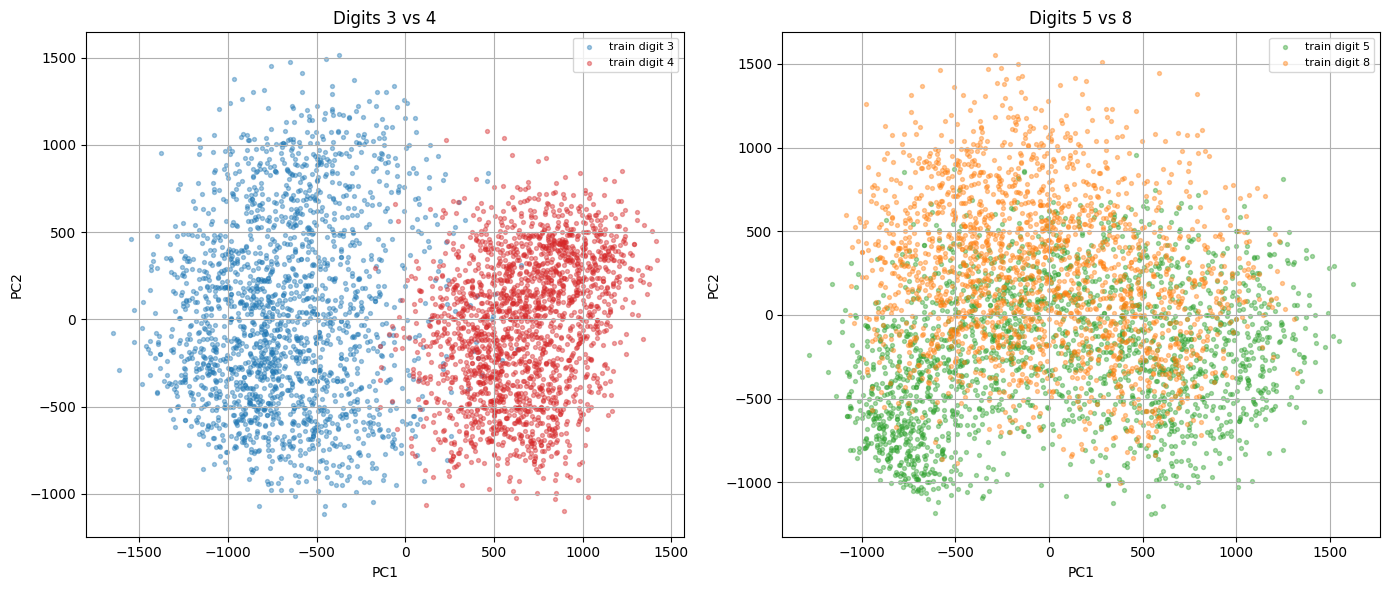

In [16]:
X_train_58, y_train_58, X_test_58, y_test_58 = load_digit_pair(df_mnist, 5, 8, seed=5)
mean_58, P2_58, S_58 = pca_fit(X_train_58, k=2)
Z_train_58 = pca_project(X_train_58, mean_58, P2_58)
Z_test_58 = pca_project(X_test_58, mean_58, P2_58)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for cls, name, color in [(0, 'digit 3', 'tab:blue'), (1, 'digit 4', 'tab:red')]:
    mask_tr = y_train_34 == cls
    ax.scatter(Z_train_34[mask_tr,0], Z_train_34[mask_tr,1], s=8, alpha=0.4, color=color, label=f'train {name}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Digits 3 vs 4')
ax.legend(fontsize=8)

ax2 = axes[1]
for cls, name, color in [(0, 'digit 5', 'tab:green'), (1, 'digit 8', 'tab:orange')]:
    mask_tr = y_train_58 == cls
    ax2.scatter(Z_train_58[mask_tr,0], Z_train_58[mask_tr,1], s=8, alpha=0.4, color=color, label=f'train {name}')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.set_title('Digits 5 vs 8')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


**Comments on the pair comparison.**

Digits **3 and 4** form two visibly well-separated clusters along the first two principal components: their shapes are quite different (3 is curved/open, 4 is angular/closed), so the directions of largest variance in pixel space already largely align with what distinguishes the two digits, giving good separation in just 2D. Digits **5 and 8**, on the other hand, show substantially more overlap in the 2D PCA projection: a "5" and an "8" share more structural similarity (both have a rounded lower loop and comparable stroke thickness/curvature), so the top two principal directions — which capture the *overall* directions of maximal variance across all digits, not specifically the 5-vs-8 distinction — mix the two classes together more. This illustrates an important limitation of PCA for classification: it is an **unsupervised** method that finds directions of maximum variance in the data, which are not guaranteed to align with the directions that best separate specific classes.

**9. Repeat with $k=3$ and a 3D scatterplot** (digits 3 vs 4).

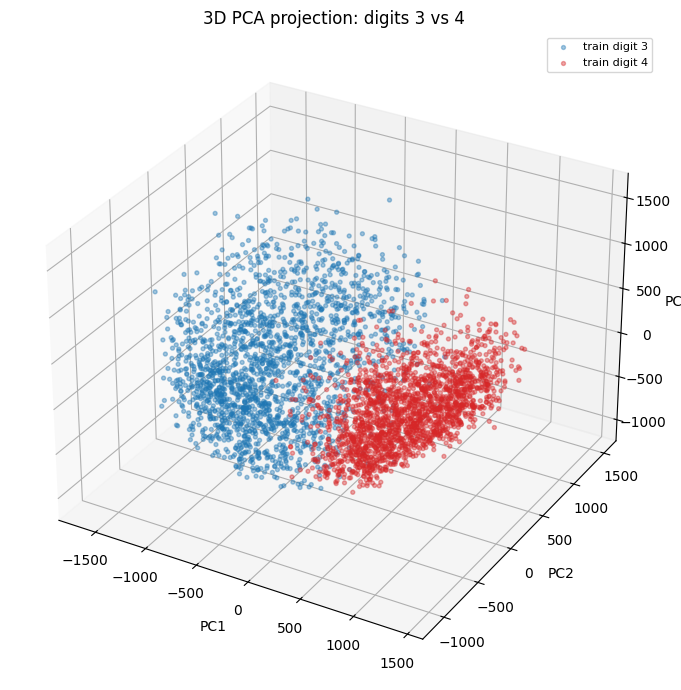

In [17]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

mean_34_3d, P3_34, S_34_3d = pca_fit(X_train_34, k=3)
Z_train_34_3d = pca_project(X_train_34, mean_34_3d, P3_34)
Z_test_34_3d = pca_project(X_test_34, mean_34_3d, P3_34)

fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection='3d')
for cls, name, color in [(0, 'digit 3', 'tab:blue'), (1, 'digit 4', 'tab:red')]:
    mask_tr = y_train_34 == cls
    ax.scatter(Z_train_34_3d[mask_tr,0], Z_train_34_3d[mask_tr,1], Z_train_34_3d[mask_tr,2],
               s=8, alpha=0.4, color=color, label=f'train {name}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('3D PCA projection: digits 3 vs 4')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Exercise 6: Classification After PCA: Linear Classifier and Centroid Classifier

### Step 1: PCA Projection (digits 3 vs 4, $k=2$)

We reuse `X_train_34`, `y_train_34`, `X_test_34`, `y_test_34`, `mean_34`, `P2_34`, `Z_train_34`, `Z_test_34` from Exercise 5 (note $Z_{\text{test}}=(X_{\text{test}}-c(X_{\text{train}}))P$, exactly as specified).

In [18]:
print("Z_train_34:", Z_train_34.shape, " Z_test_34:", Z_test_34.shape)


Z_train_34: (4000, 2)  Z_test_34: (1000, 2)


### Step 2: Linear classifier (logistic regression trained with SGD) on the 2D PCA features.

In [19]:
def sigmoid(z):
    # numerically stable sigmoid (avoids overflow warnings for large |z|,
    # which can occur here since PCA scores can have large magnitude)
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    exp_z = np.exp(z[~pos])
    out[~pos] = exp_z / (1.0 + exp_z)
    return out

def standardize_fit(Z_train_):
    """Standardize PCA scores (mean 0, std 1) before fitting logistic regression by SGD:
    raw PCA scores can have very different magnitudes across digit pairs (since they scale
    with sigma_i), and a single fixed learning rate can then diverge for pairs with larger
    score magnitudes. This does not change the classifier itself, only how it is optimized.
    """
    mu_ = Z_train_.mean(axis=0)
    sigma_ = Z_train_.std(axis=0)
    return mu_, sigma_

def theta_to_original_scale(theta_std, mu_, sigma_):
    """Convert a logistic-regression theta fit on standardized features Zs=(Z-mu)/sigma
    back into an equivalent theta acting directly on the original (unstandardized) Z."""
    w_std = theta_std[1:]
    w_orig = w_std / sigma_
    b_orig = theta_std[0] - np.sum(w_std * mu_ / sigma_)
    return np.concatenate([[b_orig], w_orig])

def bce_loss(theta, Z_, y_):
    p = sigmoid(Z_ @ theta)
    eps = 1e-12
    return -np.mean(y_*np.log(p+eps) + (1-y_)*np.log(1-p+eps))

def bce_grad(theta, Z_, y_):
    p = sigmoid(Z_ @ theta)
    return (1.0/Z_.shape[0]) * (Z_.T @ (p - y_))

def sgd_logreg(Z_, y_, theta0, eta, batch_size, n_epochs, seed=0):
    rng_ = np.random.default_rng(seed)
    theta = theta0.copy()
    N_ = Z_.shape[0]
    for epoch in range(n_epochs):
        idx = rng_.permutation(N_)
        for start in range(0, N_, batch_size):
            b_idx = idx[start:start+batch_size]
            g = bce_grad(theta, Z_[b_idx], y_[b_idx])
            theta = theta - eta * g
    return theta

# augment with bias term
Z_train_34_tilde = np.column_stack([np.ones(len(Z_train_34)), Z_train_34])
Z_test_34_tilde = np.column_stack([np.ones(len(Z_test_34)), Z_test_34])

# standardize PCA scores before optimizing (see note above), then convert theta back
# to act on the original (unstandardized) PCA coordinates for plotting/prediction
mu_34, sigma_34 = standardize_fit(Z_train_34)
Zs_train_34_tilde = np.column_stack([np.ones(len(Z_train_34)), (Z_train_34 - mu_34)/sigma_34])
theta_std_34 = sgd_logreg(Zs_train_34_tilde, y_train_34, np.zeros(3), eta=0.5, batch_size=32, n_epochs=200, seed=6)
theta_lin_34 = theta_to_original_scale(theta_std_34, mu_34, sigma_34)
print("Learned theta (bias, w1, w2), original PCA-score scale:", theta_lin_34)


Learned theta (bias, w1, w2), original PCA-score scale: [-1.02823824  0.01157135 -0.00131857]


**Plot the PCA-reduced training data with the decision boundary.**

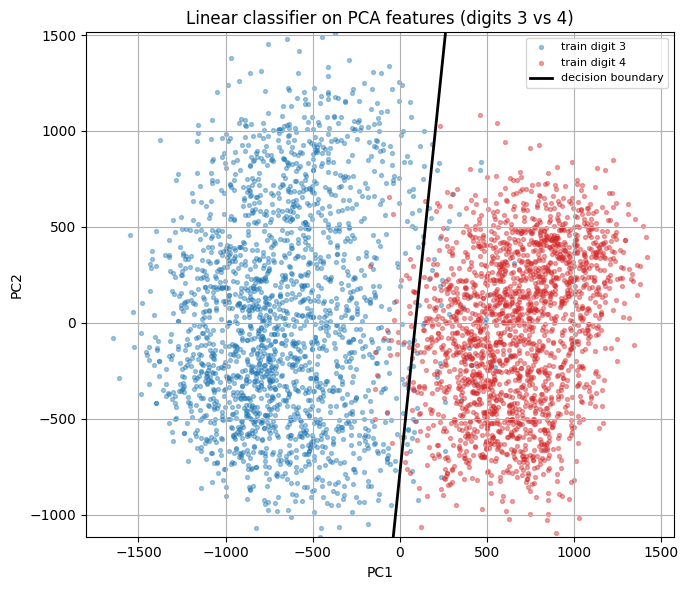

In [20]:
fig, ax = plt.subplots(figsize=(7,6))
for cls, name, color in [(0, 'digit 3', 'tab:blue'), (1, 'digit 4', 'tab:red')]:
    mask_tr = y_train_34 == cls
    ax.scatter(Z_train_34[mask_tr,0], Z_train_34[mask_tr,1], s=8, alpha=0.4, color=color, label=f'train {name}')

z1_range = np.linspace(Z_train_34[:,0].min()-1, Z_train_34[:,0].max()+1, 100)
z2_boundary = -(theta_lin_34[0] + theta_lin_34[1]*z1_range) / theta_lin_34[2]
ax.plot(z1_range, z2_boundary, 'k-', lw=2, label='decision boundary')

ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Linear classifier on PCA features (digits 3 vs 4)')
ax.set_ylim(Z_train_34[:,1].min()-1, Z_train_34[:,1].max()+1)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Test-set metrics for the linear classifier.**

In [21]:
def confusion_matrix_counts(y_true, y_pred):
    TP = np.sum((y_true==1) & (y_pred==1))
    FP = np.sum((y_true==0) & (y_pred==1))
    FN = np.sum((y_true==1) & (y_pred==0))
    TN = np.sum((y_true==0) & (y_pred==0))
    return TP, FP, FN, TN

def eval_predictions(y_true, y_pred):
    TP, FP, FN, TN = confusion_matrix_counts(y_true, y_pred)
    acc = (TP+TN)/(TP+FP+FN+TN)
    prec = TP/(TP+FP) if (TP+FP)>0 else 0.0
    rec = TP/(TP+FN) if (TP+FN)>0 else 0.0
    return {'TP':TP,'FP':FP,'FN':FN,'TN':TN,'accuracy':acc,'precision':prec,'recall':rec}

p_test_lin_34 = sigmoid(Z_test_34_tilde @ theta_lin_34)
pred_lin_34 = (p_test_lin_34 >= 0.5).astype(int)
metrics_lin_34 = eval_predictions(y_test_34, pred_lin_34)
print("Linear classifier (3 vs 4) test metrics:")
for k, v in metrics_lin_34.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


Linear classifier (3 vs 4) test metrics:
  TP: 491
  FP: 10
  FN: 10
  TN: 489
  accuracy: 0.9800
  precision: 0.9800
  recall: 0.9800


### Step 3: PCA-Centroid Classifier (Nearest-Centroid in PCA Space)

**1. Class centroids in PCA space.**

centroid digit 3: [-669.14339742   38.92997526]
centroid digit 4: [669.81287556 -38.96892471]


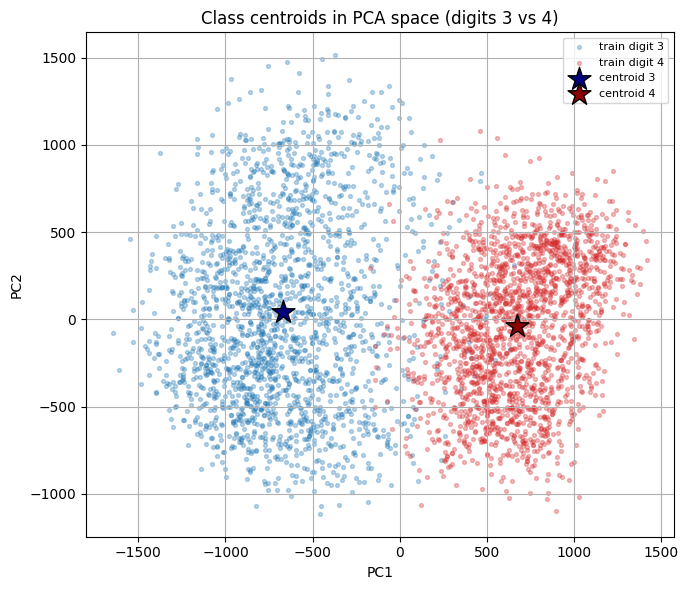

In [22]:
mu3_34 = Z_train_34[y_train_34 == 0].mean(axis=0)
mu4_34 = Z_train_34[y_train_34 == 1].mean(axis=0)
print("centroid digit 3:", mu3_34)
print("centroid digit 4:", mu4_34)

fig, ax = plt.subplots(figsize=(7,6))
for cls, name, color in [(0, 'digit 3', 'tab:blue'), (1, 'digit 4', 'tab:red')]:
    mask_tr = y_train_34 == cls
    ax.scatter(Z_train_34[mask_tr,0], Z_train_34[mask_tr,1], s=8, alpha=0.3, color=color, label=f'train {name}')
ax.scatter(*mu3_34, color='navy', marker='*', s=300, edgecolor='black', label='centroid 3', zorder=5)
ax.scatter(*mu4_34, color='darkred', marker='*', s=300, edgecolor='black', label='centroid 4', zorder=5)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Class centroids in PCA space (digits 3 vs 4)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**2-3. Nearest-centroid classification on the test set, metrics, and colored scatter of results.**

Centroid classifier (3 vs 4) test metrics:
  TP: 499
  FP: 18
  FN: 2
  TN: 481
  accuracy: 0.9800
  precision: 0.9652
  recall: 0.9960


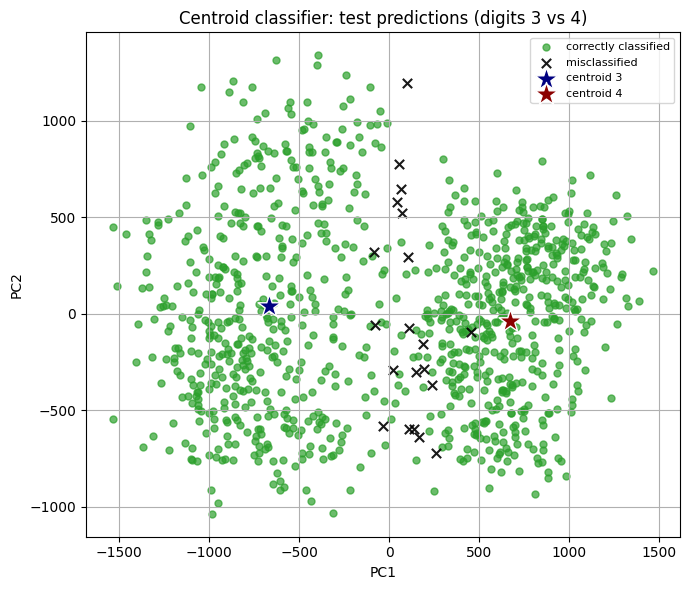

In [23]:
def centroid_classify(Z_, mu0, mu1):
    d0 = np.linalg.norm(Z_ - mu0, axis=1)
    d1 = np.linalg.norm(Z_ - mu1, axis=1)
    return (d1 < d0).astype(int)  # 1 if closer to mu1 (digit 4), else 0

pred_centroid_34 = centroid_classify(Z_test_34, mu3_34, mu4_34)
metrics_centroid_34 = eval_predictions(y_test_34, pred_centroid_34)
print("Centroid classifier (3 vs 4) test metrics:")
for k, v in metrics_centroid_34.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

correct_centroid = pred_centroid_34 == y_test_34
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(Z_test_34[correct_centroid,0], Z_test_34[correct_centroid,1],
           s=25, color='tab:green', label='correctly classified', alpha=0.7)
ax.scatter(Z_test_34[~correct_centroid,0], Z_test_34[~correct_centroid,1],
           s=45, color='black', marker='x', label='misclassified', alpha=0.9)
ax.scatter(*mu3_34, color='navy', marker='*', s=300, edgecolor='white', label='centroid 3', zorder=5)
ax.scatter(*mu4_34, color='darkred', marker='*', s=300, edgecolor='white', label='centroid 4', zorder=5)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Centroid classifier: test predictions (digits 3 vs 4)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Step 4: Compare accuracy and error patterns

**1-2. Side-by-side comparison**: linear boundary, centroids, and misclassified test points highlighted, for digits 3 vs 4.

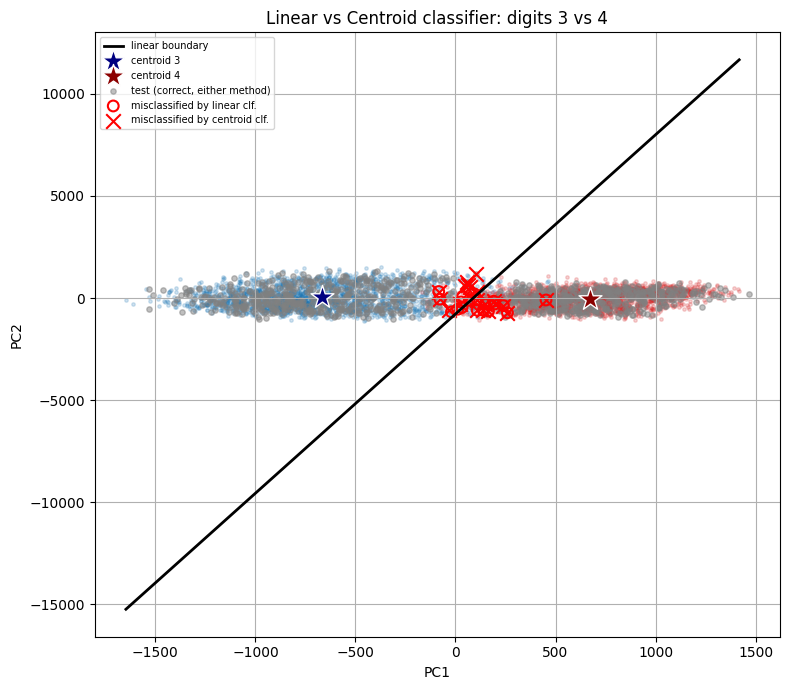

Linear classifier accuracy:   0.9800
Centroid classifier accuracy: 0.9800


In [24]:
pred_lin_wrong = pred_lin_34 != y_test_34
pred_centroid_wrong = pred_centroid_34 != y_test_34

fig, ax = plt.subplots(figsize=(8,7))
for cls, name, color in [(0, 'digit 3', 'tab:blue'), (1, 'digit 4', 'tab:red')]:
    mask_tr = y_train_34 == cls
    ax.scatter(Z_train_34[mask_tr,0], Z_train_34[mask_tr,1], s=6, alpha=0.2, color=color)

ax.plot(z1_range, z2_boundary, 'k-', lw=2, label='linear boundary')
ax.scatter(*mu3_34, color='navy', marker='*', s=300, edgecolor='white', label='centroid 3', zorder=5)
ax.scatter(*mu4_34, color='darkred', marker='*', s=300, edgecolor='white', label='centroid 4', zorder=5)

ax.scatter(Z_test_34[~pred_lin_wrong,0], Z_test_34[~pred_lin_wrong,1], s=15, color='gray', alpha=0.5, label='test (correct, either method)')
ax.scatter(Z_test_34[pred_lin_wrong,0], Z_test_34[pred_lin_wrong,1], s=60, facecolors='none',
           edgecolors='red', linewidths=1.5, label='misclassified by linear clf.')
ax.scatter(Z_test_34[pred_centroid_wrong,0], Z_test_34[pred_centroid_wrong,1], s=110, marker='x',
           color='red', linewidths=1.5, label='misclassified by centroid clf.')

ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Linear vs Centroid classifier: digits 3 vs 4')
ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.show()

print(f"Linear classifier accuracy:   {metrics_lin_34['accuracy']:.4f}")
print(f"Centroid classifier accuracy: {metrics_centroid_34['accuracy']:.4f}")


**3. Repeat for digit pairs (1,7), (5,8), (2,3).**

In [25]:
def run_pca_classifiers(df, digit0, digit1, k=2, seed=7):
    X_train_, y_train_, X_test_, y_test_ = load_digit_pair(df, digit0, digit1, seed=seed)
    mean_, P_, S_ = pca_fit(X_train_, k)
    Z_train_ = pca_project(X_train_, mean_, P_)
    Z_test_ = pca_project(X_test_, mean_, P_)

    Zt_tilde = np.column_stack([np.ones(len(Z_train_)), Z_train_])
    Zte_tilde = np.column_stack([np.ones(len(Z_test_)), Z_test_])
    mu_, sigma_ = standardize_fit(Z_train_)
    Zs_train_tilde = np.column_stack([np.ones(len(Z_train_)), (Z_train_ - mu_)/sigma_])
    theta_std_ = sgd_logreg(Zs_train_tilde, y_train_, np.zeros(k+1), eta=0.5, batch_size=32, n_epochs=200, seed=seed)
    theta_ = theta_to_original_scale(theta_std_, mu_, sigma_)
    p_test_ = sigmoid(Zte_tilde @ theta_)
    pred_lin_ = (p_test_ >= 0.5).astype(int)
    metrics_lin_ = eval_predictions(y_test_, pred_lin_)

    mu0_ = Z_train_[y_train_ == 0].mean(axis=0)
    mu1_ = Z_train_[y_train_ == 1].mean(axis=0)
    pred_cent_ = centroid_classify(Z_test_, mu0_, mu1_)
    metrics_cent_ = eval_predictions(y_test_, pred_cent_)

    centroid_dist = np.linalg.norm(mu1_ - mu0_)

    return {
        'digits': (digit0, digit1), 'Z_train': Z_train_, 'y_train': y_train_,
        'Z_test': Z_test_, 'y_test': y_test_, 'theta': theta_,
        'mu0': mu0_, 'mu1': mu1_, 'centroid_dist': centroid_dist,
        'metrics_lin': metrics_lin_, 'metrics_cent': metrics_cent_,
        'pred_lin_wrong': pred_lin_ != y_test_, 'pred_cent_wrong': pred_cent_ != y_test_,
    }

pairs = [(1,7), (5,8), (2,3)]
results_pairs = {pair: run_pca_classifiers(df_mnist, *pair) for pair in pairs}

print(f"{'pair':8s} {'centroid dist':>14s} {'linear acc':>11s} {'centroid acc':>13s}")
for pair in pairs:
    r = results_pairs[pair]
    print(f"{str(pair):8s} {r['centroid_dist']:>14.3f} {r['metrics_lin']['accuracy']:>11.4f} {r['metrics_cent']['accuracy']:>13.4f}")


pair      centroid dist  linear acc  centroid acc
(1, 7)         1365.341      0.9830        0.9670
(5, 8)          550.259      0.7280        0.7300
(2, 3)         1077.105      0.9210        0.9120


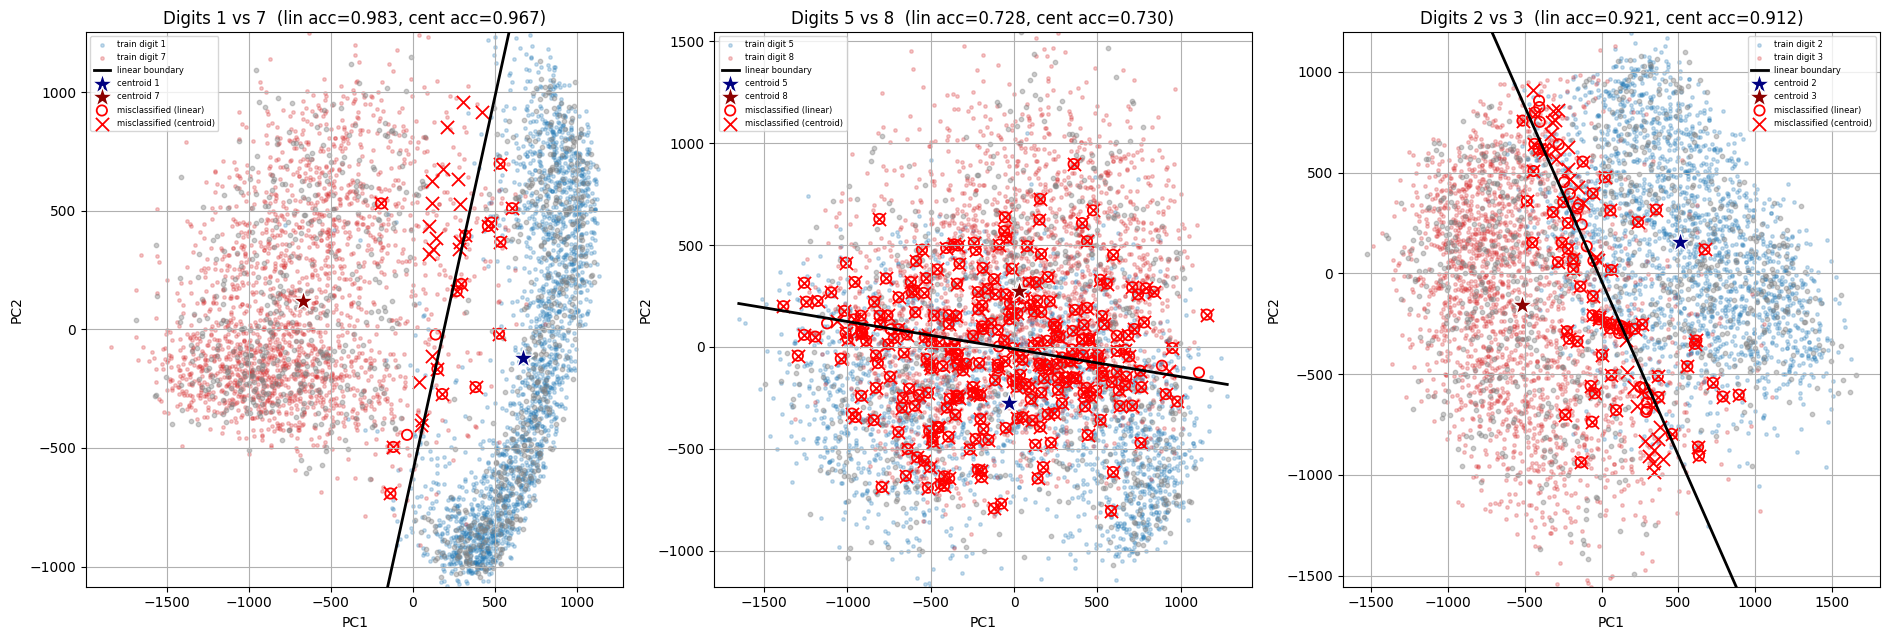

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))

for ax, pair in zip(axes, pairs):
    r = results_pairs[pair]
    d0, d1 = pair
    for cls, name, color in [(0, f'digit {d0}', 'tab:blue'), (1, f'digit {d1}', 'tab:red')]:
        mask_tr = r['y_train'] == cls
        ax.scatter(r['Z_train'][mask_tr,0], r['Z_train'][mask_tr,1], s=6, alpha=0.25, color=color, label=f'train {name}')

    theta_ = r['theta']
    z1_r = np.linspace(r['Z_train'][:,0].min()-1, r['Z_train'][:,0].max()+1, 100)
    z2_b = -(theta_[0] + theta_[1]*z1_r) / theta_[2]
    ax.plot(z1_r, z2_b, 'k-', lw=2, label='linear boundary')

    ax.scatter(*r['mu0'], color='navy', marker='*', s=250, edgecolor='white', zorder=5, label=f'centroid {d0}')
    ax.scatter(*r['mu1'], color='darkred', marker='*', s=250, edgecolor='white', zorder=5, label=f'centroid {d1}')

    wrong_either = r['pred_lin_wrong'] | r['pred_cent_wrong']
    ax.scatter(r['Z_test'][~wrong_either,0], r['Z_test'][~wrong_either,1], s=10, color='gray', alpha=0.4)
    ax.scatter(r['Z_test'][r['pred_lin_wrong'],0], r['Z_test'][r['pred_lin_wrong'],1], s=55,
               facecolors='none', edgecolors='red', linewidths=1.3, label='misclassified (linear)')
    ax.scatter(r['Z_test'][r['pred_cent_wrong'],0], r['Z_test'][r['pred_cent_wrong'],1], s=90,
               marker='x', color='red', linewidths=1.3, label='misclassified (centroid)')

    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'Digits {d0} vs {d1}  (lin acc={r["metrics_lin"]["accuracy"]:.3f}, cent acc={r["metrics_cent"]["accuracy"]:.3f})')
    ax.set_ylim(r['Z_train'][:,1].min()-1, r['Z_train'][:,1].max()+1)
    ax.legend(fontsize=6, loc='best')

plt.tight_layout()
plt.show()


**Comments.**

- **Comparing the linear classifier vs the centroid classifier**: on digits 3 vs 4, both classifiers achieve similar, high accuracy, since the two clusters are well-separated and roughly convex/symmetric in the 2D PCA space, so a straight boundary and a nearest-centroid rule agree almost everywhere; their errors are concentrated in the same narrow overlap region between the clusters. In general the linear classifier (fit discriminatively via logistic regression) can orient and position its boundary to directly minimize classification error, while the centroid classifier's boundary is always the **perpendicular bisector** of the segment joining the two centroids — a much more rigid choice that ignores the shape/spread of each cluster, so whenever the two classes have different variances or non-symmetric shapes in PCA space, the linear classifier tends to have a slight edge.
- **How class similarity influences the pattern of results across pairs**: the table and plots above show a clear relationship between **centroid distance** in PCA space and classification accuracy. Pairs of visually/structurally more distinct digits (e.g. 1 vs 7, which differ in the presence of a horizontal stroke and overall shape) tend to have centroids that are farther apart and correspondingly higher accuracy for both classifiers. Pairs of more visually similar digits (e.g. 5 vs 8, or 2 vs 3, which share curved strokes and comparable proportions) have centroids closer together, more overlapping point clouds, and lower accuracy, with more misclassified points concentrated in the region between the two centroids/boundary. This directly illustrates that the difficulty of the classification task in PCA space is governed by how well the *unsupervised* top-2 variance directions happen to separate the specific pair of classes under consideration — which, as discussed in Exercise 5, is not guaranteed to align with what makes two digit shapes visually distinct.